In [ ]:
pip install spotipy 

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install torchviz

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install plotly librosa IPython numpy pandas PIL pickle torch fastprogress 

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
import pandas as pd
import spotipy
import requests
from spotipy.oauth2 import SpotifyClientCredentials
from collections import OrderedDict
from tqdm import tqdm
import plotly.express as px
import librosa
import librosa.display
import numpy as np 
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import IPython
import IPython.display
import PIL
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from fastprogress import master_bar, progress_bar
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
from psutil import cpu_count
from sklearn.model_selection import train_test_split
import time
from collections import Counter, defaultdict
from functools import partial
from PIL import Image
from sklearn.manifold import TSNE

In [ ]:
SPOTIFY_CLIENT_ID = 'XXXXXXXXXXXXXXXXXXXX'                                                      
SPOTIFY_CLIENT_SECRET = 'XXXXXXXXXXXXXXXXXXXX'                                                  
GET_TRACK_BATCH_NUM = 50                                                                                       
GET_TRACK_NUM_PER_GENRE = 100         
assert GET_TRACK_NUM_PER_GENRE % GET_TRACK_BATCH_NUM == 0,'You must set GET_TRACK_NUM_PER_GENRE to number which can be devided by GET_TRACK_BATCH_NUM'

In [ ]:
client_id = SPOTIFY_CLIENT_ID
client_secret = SPOTIFY_CLIENT_SECRET
client_credentials_manager = spotipy.oauth2.SpotifyClientCredentials(client_id, client_secret)
spotify = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

In [ ]:
allGenres = spotify.recommendation_genre_seeds()['genres']
print('number of genre is : {}'.format(len(allGenres)))
print('all genres:')
print("\n".join(allGenres))

number of genre is : 126
all genres:
acoustic
afrobeat
alt-rock
alternative
ambient
anime
black-metal
bluegrass
blues
bossanova
brazil
breakbeat
british
cantopop
chicago-house
children
chill
classical
club
comedy
country
dance
dancehall
death-metal
deep-house
detroit-techno
disco
disney
drum-and-bass
dub
dubstep
edm
electro
electronic
emo
folk
forro
french
funk
garage
german
gospel
goth
grindcore
groove
grunge
guitar
happy
hard-rock
hardcore
hardstyle
heavy-metal
hip-hop
holidays
honky-tonk
house
idm
indian
indie
indie-pop
industrial
iranian
j-dance
j-idol
j-pop
j-rock
jazz
k-pop
kids
latin
latino
malay
mandopop
metal
metal-misc
metalcore
minimal-techno
movies
mpb
new-age
new-release
opera
pagode
party
philippines-opm
piano
pop
pop-film
post-dubstep
power-pop
progressive-house
psych-rock
punk
punk-rock
r-n-b
rainy-day
reggae
reggaeton
road-trip
rock
rock-n-roll
rockabilly
romance
sad
salsa
samba
sertanejo
show-tunes
singer-songwriter
ska
sleep
songwriter
soul
soundtracks
spanish
study


In [ ]:
GENRE_FILTER = ['classical','club','dance','edm','electro']
target_genres = []
for genre in allGenres:
  if genre in GENRE_FILTER:
    target_genres.append(genre)
print(target_genres)

['classical', 'club', 'dance', 'edm', 'electro']


In [ ]:
all_tracks = []
itter = int(GET_TRACK_NUM_PER_GENRE / GET_TRACK_BATCH_NUM)

def getTrackData(trackId, track, track_features):
      trackData = OrderedDict([
          ("track_id", trackId),
          ("track_name", track["name"]),
          ("track_url", track["external_urls"]["spotify"]),
          ("available_markets", ",".join(track["available_markets"])),
          ("disc_number", track["disc_number"]),
          ("duration_ms", track["duration_ms"]),
          ("popularity", track["popularity"]),
          ("preview_url", track["preview_url"]),
          ("track_number", track["track_number"]),
          ("acousticness", track_features["acousticness"]),
          ("danceability", track_features["danceability"]),
          ("energy", track_features["energy"]),
          ("instrumentalness", track_features["instrumentalness"]),
          ("liveness", track_features["liveness"]),
          ("loudness", track_features["loudness"]),
          ("valence", track_features["valence"]),
          ("speechiness", track_features["speechiness"]),
          ("key", track_features["key"]),
          ("mode", track_features["mode"]),
          ("tempo", track_features["tempo"]),
          ("time_signature", track_features["time_signature"]),
          ("artist_id", track["artists"][0]['id']),
          ("artist_name", track["artists"][0]['name']),
          ("artist_url", track["artists"][0]['external_urls']['spotify']),
          ("artist_type", track["artists"][0]['type']),
          ("album_url", track["album"]["external_urls"]["spotify"]),
          ("album_id", track["album"]["id"]),
          ("album_name", track["album"]["name"]),
          ("album_image_url", track["album"]["images"][0]["url"]),
          ("release_date", track["album"]["release_date"]),
          ("total_tracks", track["album"]["total_tracks"]),
          ("genre", genre),
      ])
      return trackData

def saveTrackData(trackId, trackData):
  response = requests.get(trackData['preview_url'])
  with open("/Users/shiikushota/Desktop/SpotifyData/{}.mp3".format(trackId), 'wb') as saveFile:
      saveFile.write(response.content)

def getTrackDataRecursive(genre, offset):
  item = spotify.search(q="genre:{}".format(genre) ,limit=1, offset=offset, market='US')['tracks']['items'][0]
  trackId = item['id']
  track = spotify.track(trackId)
  track_features = spotify.audio_features(trackId)[0]
  if track["preview_url"] == None:
    print("\n{} - {}'s preview mp3 file dosen't exist.".format(track["artists"][0]['name'], track["name"]))
    offset += 1
    offset = getTrackDataRecursive(genre, offset)
  else:
    trackData = getTrackData(trackId, track, track_features)
    all_tracks.append(trackData)
    saveTrackData(trackId, trackData)
  return offset

In [ ]:
# get all target genre's track
for genre in tqdm(target_genres):

  maxoffset = GET_TRACK_NUM_PER_GENRE

  for i in range(itter):
    tracks = spotify.search(q="genre:{}".format(genre) ,limit=GET_TRACK_BATCH_NUM, offset=i * GET_TRACK_BATCH_NUM, market='US')['tracks']

    for item in tracks['items']:
      trackId = item['id']
      track = spotify.track(trackId)
      track_features = spotify.audio_features(trackId)[0]

      if track["preview_url"] == None:
        print("\n{} - {}'s preview mp3 file dosen't exist.".format(track["artists"][0]['name'], track["name"]))
        maxoffset += 1
        maxoffset = getTrackDataRecursive(genre, maxoffset)
      else:
        trackData = getTrackData(trackId, track, track_features)
        all_tracks.append(trackData)
        saveTrackData(trackId, trackData)

print('\nget {} tracks'.format(len(all_tracks)))

  0%|          | 0/5 [00:00<?, ?it/s]


Ludovico Einaudi - Experience's preview mp3 file dosen't exist.

Jean-Yves Thibaudet - Dawn - From "Pride & Prejudice" Soundtrack's preview mp3 file dosen't exist.

Wolfgang Amadeus Mozart - Clarinet Quintet in A Major, K. 581: IV. Allegretto con variazioni's preview mp3 file dosen't exist.

Wolfgang Amadeus Mozart - Clarinet Quintet in A Major, K. 581: II. Larghetto's preview mp3 file dosen't exist.

Wolfgang Amadeus Mozart - Serenade in B-Flat Major, K. 361 "Gran Partita": III. Adagio's preview mp3 file dosen't exist.

Wolfgang Amadeus Mozart - Clarinet Quintet in A Major, K. 581: III. Menuetto's preview mp3 file dosen't exist.

Wolfgang Amadeus Mozart - Clarinet Quintet in A Major, K. 581: I. Allegro's preview mp3 file dosen't exist.

Ólafur Arnalds - We Contain Multitudes (from home)'s preview mp3 file dosen't exist.

Johann Sebastian Bach - St. Matthew Passion, BWV 244 / Part Two (Arr. Mendelssohn 1841): 39. Aria (Alto): "Erbarme dich"'s preview mp3 file dosen't exist.


 20%|██        | 1/5 [01:34<06:19, 94.90s/it]


Le Castle Vania - John Wick Mode's preview mp3 file dosen't exist.

Le Castle Vania - LED Spirals - Extended Version's preview mp3 file dosen't exist.

Blanke - Death Rattle's preview mp3 file dosen't exist.

HEALTH - BODY/PRISON's preview mp3 file dosen't exist.


 40%|████      | 2/5 [03:07<04:42, 94.19s/it]

...


MEDUZA - Paradise (feat. Dermot Kennedy)'s preview mp3 file dosen't exist.

Marshmello - Be Kind (with Halsey)'s preview mp3 file dosen't exist.

MEDUZA - Piece Of Your Heart's preview mp3 file dosen't exist.

Topic - Breaking Me's preview mp3 file dosen't exist.

Major Lazer - Cold Water's preview mp3 file dosen't exist.

Marshmello - Happier's preview mp3 file dosen't exist.

Swedish House Mafia - Don't You Worry Child - Radio Edit's preview mp3 file dosen't exist.

Avicii - Wake Me Up's preview mp3 file dosen't exist.

Ellie Goulding - Hate Me (with Juice WRLD)'s preview mp3 file dosen't exist.

Zedd - The Middle's preview mp3 file dosen't exist.

DJ Snake - Middle's preview mp3 file dosen't exist.

Avicii - The Nights's preview mp3 file dosen't exist.

Taio Cruz - Dynamite's preview mp3 file dosen't exist.

MEDUZA - Lose Control's preview mp3 file dosen't exist.

Taio Cruz - Break Your Heart's preview mp3 file dosen't exist.

Zedd - Good Thing (with Kehlani)'s preview mp3 file dos

 80%|████████  | 4/5 [06:38<01:39, 99.72s/it]


Billie Eilish - Therefore I Am's preview mp3 file dosen't exist.

Billie Eilish - Six Feet Under's preview mp3 file dosen't exist.

Conan Gray - Heather's preview mp3 file dosen't exist.

blackbear - hot girl bummer's preview mp3 file dosen't exist.

Tove Lo - Habits (Stay High)'s preview mp3 file dosen't exist.

BØRNS - Electric Love's preview mp3 file dosen't exist.

Zedd - Clarity's preview mp3 file dosen't exist.

Jessie J - Bang Bang's preview mp3 file dosen't exist.

blackbear - do re mi's preview mp3 file dosen't exist.

Billie Eilish - everything i wanted's preview mp3 file dosen't exist.

blackbear - queen of broken hearts's preview mp3 file dosen't exist.

Billie Eilish - bad guy's preview mp3 file dosen't exist.

Conan Gray - Maniac's preview mp3 file dosen't exist.

Sabrina Carpenter - Skin's preview mp3 file dosen't exist.

Billie Eilish - COPYCAT's preview mp3 file dosen't exist.

Ryn Weaver - Pierre's preview mp3 file dosen't exist.

WILLOW - Wait a Minute!'s preview mp

100%|██████████| 5/5 [08:27<00:00, 101.59s/it]


get 1000 tracks


In [ ]:
df = pd.DataFrame(all_tracks)
df.to_csv("/Users/shiikushota/Desktop/SpotifyData/all_tracks.csv")

In [ ]:
df = pd.read_csv("/Users/shiikushota/Desktop/SpotifyData/all_tracks.csv", index_col=0)
df.head()

,track_id,track_name,track_url,available_markets,disc_number,duration_ms,popularity,preview_url,track_number,acousticness,...,artist_name,artist_url,artist_type,album_url,album_id,album_name,album_image_url,release_date,total_tracks,genre
0,7fO08kJEz8uyzAMrHlQfP2,"Piano Sonata No. 11 in A Major, K. 331: III. A...",https://open.spotify.com/track/7fO08kJEz8uyzAM...,"WS,NZ,TO,FJ,KI,MH,NR,TV,AU,FM,SB,VU,PG,JP,KR,P...",1,214095,0,https://p.scdn.co/mp3-preview/099c8c893008645d...,37,0.974,...,Wolfgang Amadeus Mozart,https://open.spotify.com/artist/4NJhFmfw43RLBL...,artist,https://open.spotify.com/album/3cWaJ4pGFoypvos...,3cWaJ4pGFoypvosPmuGSiV,Für Elise: Perfect Piano,https://i.scdn.co/image/ab67616d0000b27375f942...,2021-03-06,40,classical
1,61dYvvfIRtIDFuqZypPAta,"Cello Suite No. 1 in G Major, BWV 1007: I. Pré...",https://open.spotify.com/track/61dYvvfIRtIDFuq...,"AD,AE,AG,AL,AM,AR,AT,AU,AZ,BA,BB,BD,BE,BF,BG,B...",1,151480,64,https://p.scdn.co/mp3-preview/b4c714f0fcb97a65...,1,0.900,...,Johann Sebastian Bach,https://open.spotify.com/artist/5aIqB5nVVvmFsv...,artist,https://open.spotify.com/album/2OpnKgmVYPEN2Gl...,2OpnKgmVYPEN2GldgBponI,Bach: Unaccompanied Cello Suites (Remastered),https://i.scdn.co/image/ab67616d0000b273261feb...,1983,36,classical
2,0jOnZhF75V68VsBObWx2XO,"The Carnival of the Animals, R. 125: XIII. The...",https://open.spotify.com/track/0jOnZhF75V68VsB...,"AD,AE,AG,AL,AM,AR,AT,AU,AZ,BA,BB,BD,BE,BF,BG,B...",1,174266,69,https://p.scdn.co/mp3-preview/28857efb335b1ca1...,14,0.986,...,Camille Saint-Saëns,https://open.spotify.com/artist/436sYg6CZhNefQ...,artist,https://open.spotify.com/album/2y85NsbsBnGTXcX...,2y85NsbsBnGTXcXgHpj3PD,Songs from the Arc of Life,https://i.scdn.co/image/ab67616d0000b273cdf367...,2015-09-18,19,classical
3,5u5aVJKjSMJr4zesMPz7bL,"Clair de Lune, L. 32",https://open.spotify.com/track/5u5aVJKjSMJr4ze...,"AD,AE,AG,AL,AM,AR,AT,AU,AZ,BA,BB,BD,BE,BF,BG,B...",1,268000,68,https://p.scdn.co/mp3-preview/79531c59dbfc3679...,1,0.994,...,Claude Debussy,https://open.spotify.com/artist/1Uff91EOsvd99r...,artist,https://open.spotify.com/album/4O5tv6jrLH80bml...,4O5tv6jrLH80bmll46xEEe,Debussy: Clair De Lune and Other Piano Favourites,https://i.scdn.co/image/ab67616d0000b2736e7bb2...,1994,20,classical
4,5aLKDJOyx8gI49nDXQ8dhs,Ombre,https://open.spotify.com/track/5aLKDJOyx8gI49n...,"WS,NZ,TO,FJ,KI,MH,NR,TV,AU,FM,SB,VU,PG,JP,KR,P...",1,312257,0,https://p.scdn.co/mp3-preview/8991e7fc40b8a9c4...,27,0.991,...,Ludovico Einaudi,https://open.spotify.com/artist/2uFUBdaVGtyMqc...,artist,https://open.spotify.com/album/3L65Y16VfGMpJ5W...,3L65Y16VfGMpJ5WLRzt1sy,Coffee & Classical Music,https://i.scdn.co/image/ab67616d0000b2739b109f...,2021-03-06,50,classical


/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/display.py:974: MatplotlibDeprecationWarning: The 'basey' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  scaler(mode, **kwargs)
/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/display.py:974: MatplotlibDeprecationWarning: The 'linthreshy' parameter of __init__() has been renamed 'linthresh' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  scaler(mode, **kwargs)


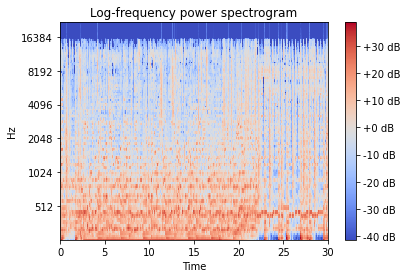

In [ ]:
def read_audio(conf, pathname, trim_long_data):
    y, sr = librosa.load(pathname, sr=conf.sampling_rate)
    if 0 < len(y): 
        y, _ = librosa.effects.trim(y) 
    if len(y) > conf.samples: 
        if trim_long_data:
            y = y[0:0+conf.samples]
    else: 
        padding = conf.samples - len(y)    
        offset = padding // 2
        y = np.pad(y, (offset, conf.samples - len(y) - offset), 'constant')
    return y

def audio_to_melspectrogram(conf, audio):
    spectrogram = librosa.feature.melspectrogram(audio, 
                                                 sr=conf.sampling_rate,
                                                 n_mels=conf.n_mels,
                                                 hop_length=conf.hop_length,
                                                 n_fft=conf.n_fft,
                                                 fmin=conf.fmin,
                                                 fmax=conf.fmax)
    spectrogram = librosa.power_to_db(spectrogram)
    spectrogram = spectrogram.astype(np.float32)
    return spectrogram

def show_melspectrogram(conf, mels, title='Log-frequency power spectrogram'):
    librosa.display.specshow(mels, x_axis='time', y_axis='mel', 
                             sr=conf.sampling_rate, hop_length=conf.hop_length,
                            fmin=conf.fmin, fmax=conf.fmax)
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show()

def read_as_melspectrogram(conf, pathname, trim_long_data, debug_display=False):
    x = read_audio(conf, pathname, trim_long_data)
    mels = audio_to_melspectrogram(conf, x)
    if debug_display:
        IPython.display.display(IPython.display.Audio(x, rate=conf.sampling_rate))
        show_melspectrogram(conf, mels)
    return mels


class conf:
    sampling_rate = 44100
    duration = 2
    hop_length = 347*duration 
    fmin = 20
    fmax = sampling_rate // 2
    n_mels = 128
    n_fft = n_mels * 20
    samples = sampling_rate * duration

x = read_as_melspectrogram(conf, "/Users/shiikushota/Desktop/SpotifyData/7BKLCZ1jbUBVqRi2FVlTVw.mp3", trim_long_data=False, debug_display=True)

In [ ]:
def mono_to_color(X, mean=None, std=None, norm_max=None, norm_min=None, eps=1e-6):
  
    X = np.stack([X, X, X], axis=-1)

    mean = mean or X.mean()
    std = std or X.std()
    Xstd = (X - mean) / (std + eps)
    _min, _max = Xstd.min(), Xstd.max()
    norm_max = norm_max or _max
    norm_min = norm_min or _min
    if (_max - _min) > eps:
        V = Xstd
        V[V < norm_min] = norm_min
        V[V > norm_max] = norm_max
        V = 255 * (V - norm_min) / (norm_max - norm_min)
        V = V.astype(np.uint8)
    else:
        V = np.zeros_like(Xstd, dtype=np.uint8)
    return V

def convert_wav_to_image(df, source, img_dest):
    X = []
    for i, row in tqdm(df.iterrows()):
        x = read_as_melspectrogram(conf, source/str(row.track_id + ".mp3"), trim_long_data=False)
        x_color = mono_to_color(x)
        X.append(x_color)
    return X

X_train = convert_wav_to_image(df, source=Path('/Users/shiikushota/Dropbox/My Mac (shiihisoutasAir)/Desktop/SpotifyData/'), img_dest=Path('/Users/shiikushota/Dropbox/My Mac (shiihisoutasAir)/Desktop/SpotifyData/'))

0it [00:00, ?it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
1it [00:00,  2.93it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
2it [00:00,  3.37it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
3it [00:00,  3.75it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
4it [00:00,  4.16it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8

35it [00:06,  5.27it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
36it [00:06,  5.39it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
37it [00:06,  5.38it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
38it [00:07,  5.40it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
39it [00:07,  5.40it/s]/Users/shiikushota/opt/anaconda3/lib/

70it [00:12,  5.55it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
71it [00:13,  5.60it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
72it [00:13,  5.63it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
73it [00:13,  5.63it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
74it [00:13,  5.62it/s]/Users/shiikushota/opt/anaconda3/lib/

105it [00:19,  5.51it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
106it [00:19,  5.57it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
107it [00:19,  5.60it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
108it [00:19,  5.52it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
109it [00:19,  5.55it/s]/Users/shiikushota/opt/anaconda3

140it [00:25,  5.54it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
141it [00:25,  5.54it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
142it [00:25,  5.57it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
143it [00:26,  5.60it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
144it [00:26,  5.57it/s]/Users/shiikushota/opt/anaconda3

...

840it [02:32,  5.35it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
841it [02:32,  5.41it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
842it [02:32,  5.23it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
843it [02:32,  5.30it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
844it [02:32,  5.16it/s]/Users/shiikushota/opt/anaconda3

875it [02:38,  5.41it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
876it [02:38,  5.27it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
877it [02:38,  5.34it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
878it [02:39,  5.36it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
879it [02:39,  5.37it/s]/Users/shiikushota/opt/anaconda3

910it [02:45,  5.33it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
911it [02:45,  5.31it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
912it [02:45,  5.32it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
913it [02:45,  5.36it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
914it [02:46,  5.34it/s]/Users/shiikushota/opt/anaconda3

945it [02:52,  4.99it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
946it [02:52,  5.09it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
947it [02:52,  5.10it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
948it [02:52,  5.09it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
949it [02:53,  5.07it/s]/Users/shiikushota/opt/anaconda3

980it [02:59,  4.68it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
981it [02:59,  4.79it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
982it [02:59,  4.89it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
983it [03:00,  4.79it/s]/Users/shiikushota/opt/anaconda3/lib/python3.8/site-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
984it [03:00,  4.87it/s]/Users/shiikushota/opt/anaconda3